# Netflix Content Analysis — Exploratory Data Analysis (EDA)

## Objective: 
Netflix's public catalog metadata is analyzed to understand what kind of content Netflix offers and how it has grown over time. 

Specifically, this notebook answers:- 
- What is the split between Movies and TV Shows on Netflix?
- Which countries, directors, and genres contribute the most content?
- How is content distributed across age-rating categories (Kids / Teens / Adults)?
- How has content addition trended over the years, months, and days of the week?
- What is the typical runtime of movies and typical number of seasons for TV shows?

## Dataset- **Source:** Netflix Titles dataset (Kaggle) — `netflix.csv`
 - **Original size:** 8,807 rows × 12 columns
- **Key columns:** `type`, `title`, `director`, `cast`, `country`, `date_added`, `release_year`, `rating`, `duration`, `listed_in` (genre), `description`

## Tools Used-
`pandas`, `numpy`, `matplotlib`, `seaborn`

## Approach: 
- 1. Clean the raw data (handle nulls, duplicates, inconsistent formats).
- 2. Unnest multi-value columns (`cast`, `director`, `country`, `genre` — each title can have several of each) into a long-format dataframe for accurate counting.
- 3. Perform univariate analysis with visualizations and derive insights for each4. Summarize key findings and business takeaways at the end.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
df = pd.read_csv("netflix.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [7]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

Renaming  the  listed in column to genres

In [8]:
df.rename(columns={'listed_in':'genre'},inplace=True)
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genre', 'description'],
      dtype='object')

Dropping the show_id column as it may be of no use in the analysis

In [9]:
df.drop(columns='show_id',inplace=True)

Checking for the duplicates

In [10]:
df.duplicated().sum()

np.int64(0)

Checking the missing values

In [11]:
df.isnull().sum()

type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
genre              0
description        0
dtype: int64

In [12]:
#here we can see clearly here some count are so big and some are so small
#which is available in less quantity., So we will drop them.


In [13]:
df.shape

(8807, 11)

Dropping the rows which have null values in date_added column as there are only 10 values.

In [14]:
df.dropna(subset = ['date_added'], inplace=True)
df['date_added'].isna().sum()

np.int64(0)

Dropping the rows which have null values in rating column as there are only 4 values 

In [15]:
df.dropna(subset = ['rating'], inplace=True)
df['rating'].isna().sum()

np.int64(0)

Dropping the rows which have null values in duration column as there are only 3 values

In [16]:
df.dropna(subset = ['duration'],inplace=True)
df['duration'].isna().sum()

np.int64(0)

In [17]:
 df.isnull().sum()

type               0
title              0
director        2621
cast             825
country          829
date_added         0
release_year       0
rating             0
duration           0
genre              0
description        0
dtype: int64

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8790 entries, 0 to 8806
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   type          8790 non-null   object
 1   title         8790 non-null   object
 2   director      6169 non-null   object
 3   cast          7965 non-null   object
 4   country       7961 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   genre         8790 non-null   object
 10  description   8790 non-null   object
dtypes: int64(1), object(10)
memory usage: 824.1+ KB


In [19]:
#when there is some mismatch in our date format then that value is replaced by null

df['date_added' ]=pd. to_datetime(df['date_added'], errors='coerce')
df['date_added'].isnull().sum()

np.int64(88)

In [20]:
df.dropna(subset = ['date_added' ],inplace=True)
df['date_added'].isna().sum()

np.int64(0)

Adding day, month, year, month_name, day_name as seperate columns to the dataframe

In [21]:
df['day'] = df['date_added' ].dt.day
df['month' ] = df['date_added' ].dt. month
df['year' ] = df['date_added' ].dt. year
df['month_name' ] = df['date_added' ].dt.month_name()
df['weekday' ] = df['date_added' ].dt. day_name()
df.head()

,type,title,director,cast,country,date_added,release_year,rating,duration,genre,description,day,month,year,month_name,weekday
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,24,9,2021,September,Friday
3,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",24,9,2021,September,Friday
4,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,24,9,2021,September,Friday


In [22]:
df["duration"].unique()

array(['90 min', '2 Seasons', '1 Season', '91 min', '125 min',
       '9 Seasons', '104 min', '127 min', '4 Seasons', '67 min', '94 min',
       '5 Seasons', '161 min', '61 min', '166 min', '147 min', '103 min',
       '97 min', '106 min', '111 min', '3 Seasons', '110 min', '105 min',
       '96 min', '124 min', '116 min', '98 min', '23 min', '115 min',
       '122 min', '99 min', '88 min', '100 min', '6 Seasons', '102 min',
       '93 min', '95 min', '85 min', '83 min', '113 min', '13 min',
       '182 min', '48 min', '145 min', '87 min', '92 min', '80 min',
       '117 min', '128 min', '119 min', '143 min', '114 min', '118 min',
       '108 min', '63 min', '121 min', '142 min', '154 min', '120 min',
       '82 min', '109 min', '101 min', '86 min', '229 min', '76 min',
       '89 min', '156 min', '112 min', '107 min', '129 min', '135 min',
       '136 min', '165 min', '150 min', '133 min', '70 min', '84 min',
       '140 min', '78 min', '7 Seasons', '64 min', '59 min', '139 min',
    

In [23]:
s1='179 min'
int(s1.split()[0])

179

In [24]:
s2='12 Seasons'
int(s2.split()[0])

12

In [25]:
df["duration"]=df["duration"].apply(lambda x:int(x.split()[0]))

In [26]:
df["duration"].unique()

array([ 90,   2,   1,  91, 125,   9, 104, 127,   4,  67,  94,   5, 161,
        61, 166, 147, 103,  97, 106, 111,   3, 110, 105,  96, 124, 116,
        98,  23, 115, 122,  99,  88, 100,   6, 102,  93,  95,  85,  83,
       113,  13, 182,  48, 145,  87,  92,  80, 117, 128, 119, 143, 114,
       118, 108,  63, 121, 142, 154, 120,  82, 109, 101,  86, 229,  76,
        89, 156, 112, 107, 129, 135, 136, 165, 150, 133,  70,  84, 140,
        78,   7,  64,  59, 139,  69, 148, 189, 141, 130, 138,  81, 132,
        10, 123,  65,  68,  66,  62,  74, 131,  39,  46,  38,   8,  17,
       126, 155, 159, 137,  12, 273,  36,  34,  77,  60,  49,  58,  72,
       204, 212,  25,  73,  29,  47,  32,  35,  71, 149,  33,  15,  54,
       224, 162,  37,  75,  79,  55, 158, 164, 173, 181, 185,  21,  24,
        51, 151,  42,  22, 134, 177,  52,  14,  53,  57,  28,  50,  26,
        45, 171,  27,  44, 146,  20, 157, 203,  41,  30, 194, 233, 237,
       230, 195, 253, 152, 190, 160, 208, 180, 144, 174, 170, 19

Checking for unique values of rating and categorising them for better understanding

In [27]:
df['rating'].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', 'NR', 'TV-Y7-FV', 'UR'], dtype=object)

Netflix has officially categorised theese into 3 main categories(https://help.netflix.com/en/node/2064/us)

Replacing 'TV-Y','TV-Y7','G','TV-G','PG','TV-PG','TV-Y7-FV' to Kids,

'PG-13','TV-14' to Teens,

'R','TV-MA','NC-17' to Adults,

and 'NR','UR' to null values

In [28]:
df['rating' ] = df['rating'].replace(['TV-Y', 'TV-Y7', 'G','TV-G','PG','TV-PG','TV-Y7-FV'], 'Kids')
df['rating'] = df['rating'].replace(['PG-13', 'TV-14'], 'Teens')
df['rating'] = df['rating'].replace(['R','TV-MA','NC-17'],'Adults')
df['rating'] = df['rating'].replace(['NR','UR'],np.nan)
df.head()

,type,title,director,cast,country,date_added,release_year,rating,duration,genre,description,day,month,year,month_name,weekday
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,Teens,90,Documentaries,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,Adults,1,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,24,9,2021,September,Friday
3,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,Adults,1,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",24,9,2021,September,Friday
4,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,Adults,2,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,24,9,2021,September,Friday


In [29]:
df['rating'].isna().sum()

np.int64(81)

In [30]:
df.dropna(subset = ['rating'], inplace=True)
df['rating'].isna().sum()

np.int64(0)

81 values were null, wich was only about 1%of the data, so we delete those rowss.

In [31]:
df.isna().sum()

type               0
title              0
director        2535
cast             800
country          826
date_added         0
release_year       0
rating             0
duration           0
genre              0
description        0
day                0
month              0
year               0
month_name         0
weekday            0
dtype: int64

In [32]:
df[(df['director'].isna()) & (df['country'].isna()) & (df['cast'].isna())].shape[0]

96

we have found that total 96 rows are there which dont have director, country and cast

In [33]:
df.shape

(8621, 16)

In [34]:
df.dropna(subset = ['director', 'country', 'cast'], how = 'all', inplace = True)
df.shape

(8525, 16)

In [35]:
df.isna().sum()

type               0
title              0
director        2439
cast             704
country          730
date_added         0
release_year       0
rating             0
duration           0
genre              0
description        0
day                0
month              0
year               0
month_name         0
weekday            0
dtype: int64

### Data Cleaning Summary:
Starting from the raw dataset of **8,807 rows x 11 columns** (after dropping `show_id` and renaming `listed_in` to `genre`),
The following cleaning steps were applied:- **Missing `date_added`** -> 10 rows dropped (negligible share of data)- **Missing `rating`** -> 4 rows dropped (negligible share of data)- **Missing `duration`** -> 3 rows dropped (negligible share of data)- **Invalid/unparseable `date_added`** after datetime conversion -> 88 rows dropped (could not be parsed as a valid date)- **`rating` values `NR`/`UR`** (undefined ratings) -> mapped to null, then dropped -> 81 rows removed (~1% of data, not mappable to Kids/Teens/Adults)- **Rows missing `director`, `country`, AND `cast` simultaneously** -> 96 rows dropped (no usable metadata for any of the three fields)**Result:** Cleaned dataset reduced to **8,525 rows x 16 columns** before unnesting, with `rating` standardized into three audience categories -- **Kids, Teens, Adults** -- based on [Netflix's official classification](https://help.netflix.com/en/node/2064/us).

In [36]:
df["cast"][2].split(", ")

['Sami Bouajila',
 'Tracy Gotoas',
 'Samuel Jouy',
 'Nabiha Akkari',
 'Sofia Lesaffre',
 'Salim Kechiouche',
 'Noureddine Farihi',
 'Geert Van Rampelberg',
 'Bakary Diombera']

In [37]:
df_cast = pd.DataFrame(df['cast'].apply(lambda x : str(x).split(', ')).tolist(),index = df['title'])
df_cast

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
title,,,,,,,,,,,,,,,,,,,,,
Dick Johnson Is Dead,nan,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
Blood & Water,Ama Qamata,Khosi Ngema,Gail Mabalane,Thabang Molaba,Dillon Windvogel,Natasha Thahane,Arno Greeff,Xolile Tshabalala,Getmore Sithole,Cindy Mahlangu,...,None,None,None,None,None,None,None,None,None,None
Ganglands,Sami Bouajila,Tracy Gotoas,Samuel Jouy,Nabiha Akkari,Sofia Lesaffre,Salim Kechiouche,Noureddine Farihi,Geert Van Rampelberg,Bakary Diombera,None,...,None,None,None,None,None,None,None,None,None,None
Kota Factory,Mayur More,Jitendra Kumar,Ranjan Raj,Alam Khan,Ahsaas Channa,Revathi Pillai,Urvi Singh,Arun Kumar,None,None,...,None,None,None,None,None,None,None,None,None,None
Midnight Mass,Kate Siegel,Zach Gilford,Hamish Linklater,Henry Thomas,Kristin Lehman,Samantha Sloyan,Igby Rigney,Rahul Kohli,Annarah Cymone,Annabeth Gish,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zinzana,Ali Suliman,Saleh Bakri,Yasa,Ali Al-Jabri,Mansoor Alfeeli,Ahd,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
Zodiac,Mark Ruffalo,Jake Gyllenhaal,Robert Downey Jr.,Anthony Edwards,Brian Cox,Elias Koteas,Donal Logue,John Carroll Lynch,Dermot Mulroney,Chloë Sevigny,...,None,None,None,None,None,None,None,None,None,None
Zombieland,Jesse Eisenberg,Woody Harrelson,Emma Stone,Abigail Breslin,Amber Heard,Bill Murray,Derek Graf,None,None,None,...,None,None,None,None,None,None,None,None,None,None


In [38]:
df_cast = df_cast.stack()
df_cast

title                  
Dick Johnson Is Dead  0                      nan
Blood & Water         0               Ama Qamata
                      1              Khosi Ngema
                      2            Gail Mabalane
                      3           Thabang Molaba
                                   ...          
Zubaan                3         Manish Chaudhary
                      4             Meghna Malik
                      5            Malkeet Rauni
                      6           Anita Shabdish
                      7    Chittaranjan Tripathy
Length: 63644, dtype: object

In [39]:
df_cast = pd.DataFrame(df_cast)
df_cast

0
title                                        
Dick Johnson Is Dead 0                    nan
Blood & Water        0             Ama Qamata
                     1            Khosi Ngema
                     2          Gail Mabalane
                     3         Thabang Molaba
...                                       ...
Zubaan               3       Manish Chaudhary
                     4           Meghna Malik
                     5          Malkeet Rauni
                     6         Anita Shabdish
                     7  Chittaranjan Tripathy

[63644 rows x 1 columns]

In [40]:
df_cast.reset_index(inplace=True)
df_cast

,title,level_1,0
0,Dick Johnson Is Dead,0,nan
1,Blood & Water,0,Ama Qamata
2,Blood & Water,1,Khosi Ngema
3,Blood & Water,2,Gail Mabalane
4,Blood & Water,3,Thabang Molaba
...,...,...,...
63639,Zubaan,3,Manish Chaudhary
63640,Zubaan,4,Meghna Malik
63641,Zubaan,5,Malkeet Rauni
63642,Zubaan,6,Anita Shabdish


In [41]:
df_cast = df_cast[['title', 0 ]]
df_cast

,title,0
0,Dick Johnson Is Dead,nan
1,Blood & Water,Ama Qamata
2,Blood & Water,Khosi Ngema
3,Blood & Water,Gail Mabalane
4,Blood & Water,Thabang Molaba
...,...,...
63639,Zubaan,Manish Chaudhary
63640,Zubaan,Meghna Malik
63641,Zubaan,Malkeet Rauni
63642,Zubaan,Anita Shabdish


In [42]:
df_cast.columns=['title', 'cast']
df_cast

,title,cast
0,Dick Johnson Is Dead,nan
1,Blood & Water,Ama Qamata
2,Blood & Water,Khosi Ngema
3,Blood & Water,Gail Mabalane
4,Blood & Water,Thabang Molaba
...,...,...
63639,Zubaan,Manish Chaudhary
63640,Zubaan,Meghna Malik
63641,Zubaan,Malkeet Rauni
63642,Zubaan,Anita Shabdish


In [43]:
df_cast.replace('nan' , np.nan, inplace=True)
df_cast.isna().sum()

C:\Users\krish\AppData\Local\Temp\ipykernel_22132\2713866712.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cast.replace('nan' , np.nan, inplace=True)


title      0
cast     704
dtype: int64

In [44]:
df_genre = pd.DataFrame(df['genre' ]. apply(lambda x: str(x) .split(', ')).tolist(), index=df['title'])
df_genre = df_genre.stack()
df_genre = pd.DataFrame(df_genre)
df_genre.reset_index(inplace=True)
df_genre = df_genre[['title',0]]
df_genre.columns =['title','genre']
df_genre.replace('nan',np.nan, inplace=True)
df_genre.isna().sum()

title    0
genre    0
dtype: int64

In [45]:
df_director = pd.DataFrame(df['director' ].apply(lambda x: str(x). split(', ')).tolist(),index=df['title'])
df_director = df_director. stack()
df_director = pd. DataFrame(df_director)
df_director.reset_index(inplace=True)
df_director = df_director[['title',0]]
df_director.columns =['title', 'director']
df_director.replace('nan',np. nan, inplace=True)
df_director.isna().sum()

title          0
director    2439
dtype: int64

In [46]:
df_country = pd.DataFrame(df['country' ]. apply(lambda x: str(x).split(', ')).tolist(),index=df['title'])
df_country = df_country. stack()
df_country = pd.DataFrame(df_country)
df_country.reset_index(inplace=True)
df_country = df_country[['title',0]]
df_country.columns =['title','country']
df_country.replace('nan',np.nan, inplace=True)
df_country.isna().sum()

title        0
country    730
dtype: int64

In [47]:
df12 = df_cast.merge(df_genre, on = 'title')
df12

,title,cast,genre
0,Dick Johnson Is Dead,NaN,Documentaries
1,Blood & Water,Ama Qamata,International TV Shows
2,Blood & Water,Ama Qamata,TV Dramas
3,Blood & Water,Ama Qamata,TV Mysteries
4,Blood & Water,Khosi Ngema,International TV Shows
...,...,...,...
146662,Zubaan,Anita Shabdish,International Movies
146663,Zubaan,Anita Shabdish,Music & Musicals
146664,Zubaan,Chittaranjan Tripathy,Dramas
146665,Zubaan,Chittaranjan Tripathy,International Movies


In [48]:
df123 = df_director.merge(df12, on ='title')
df123

,title,director,cast,genre
0,Dick Johnson Is Dead,Kirsten Johnson,NaN,Documentaries
1,Blood & Water,NaN,Ama Qamata,International TV Shows
2,Blood & Water,NaN,Ama Qamata,TV Dramas
3,Blood & Water,NaN,Ama Qamata,TV Mysteries
4,Blood & Water,NaN,Khosi Ngema,International TV Shows
...,...,...,...,...
158309,Zubaan,Mozez Singh,Anita Shabdish,International Movies
158310,Zubaan,Mozez Singh,Anita Shabdish,Music & Musicals
158311,Zubaan,Mozez Singh,Chittaranjan Tripathy,Dramas
158312,Zubaan,Mozez Singh,Chittaranjan Tripathy,International Movies


In [49]:
df1234 = df_country.merge(df123, on ='title')
df1234

,title,country,director,cast,genre
0,Dick Johnson Is Dead,United States,Kirsten Johnson,NaN,Documentaries
1,Blood & Water,South Africa,NaN,Ama Qamata,International TV Shows
2,Blood & Water,South Africa,NaN,Ama Qamata,TV Dramas
3,Blood & Water,South Africa,NaN,Ama Qamata,TV Mysteries
4,Blood & Water,South Africa,NaN,Khosi Ngema,International TV Shows
...,...,...,...,...,...
198399,Zubaan,India,Mozez Singh,Anita Shabdish,International Movies
198400,Zubaan,India,Mozez Singh,Anita Shabdish,Music & Musicals
198401,Zubaan,India,Mozez Singh,Chittaranjan Tripathy,Dramas
198402,Zubaan,India,Mozez Singh,Chittaranjan Tripathy,International Movies


In [50]:
df_new = df.merge(df1234,on="title")
df_new

,type,title,director_x,cast_x,country_x,date_added,release_year,rating,duration,genre_x,description,day,month,year,month_name,weekday,country_y,director_y,cast_y,genre_y
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,Teens,90,Documentaries,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday,United States,Kirsten Johnson,NaN,Documentaries
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Ama Qamata,International TV Shows
2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Ama Qamata,TV Dramas
3,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Ama Qamata,TV Mysteries
4,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Khosi Ngema,International TV Shows
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198399,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,Teens,111,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday,India,Mozez Singh,Anita Shabdish,International Movies
198400,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,Teens,111,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday,India,Mozez Singh,Anita Shabdish,Music & Musicals
198401,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,Teens,111,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday,India,Mozez Singh,Chittaranjan Tripathy,Dramas
198402,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,Teens,111,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday,India,Mozez Singh,Chittaranjan Tripathy,International Movies


In [51]:
df_new. drop(columns = ['cast_x', 'country_x', 'director_x', 'genre_x' ], inplace=True)
df_new

,type,title,date_added,release_year,rating,duration,description,day,month,year,month_name,weekday,country_y,director_y,cast_y,genre_y
0,Movie,Dick Johnson Is Dead,2021-09-25,2020,Teens,90,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday,United States,Kirsten Johnson,NaN,Documentaries
1,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Ama Qamata,International TV Shows
2,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Ama Qamata,TV Dramas
3,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Ama Qamata,TV Mysteries
4,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Khosi Ngema,International TV Shows
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198399,Movie,Zubaan,2019-03-02,2015,Teens,111,A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday,India,Mozez Singh,Anita Shabdish,International Movies
198400,Movie,Zubaan,2019-03-02,2015,Teens,111,A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday,India,Mozez Singh,Anita Shabdish,Music & Musicals
198401,Movie,Zubaan,2019-03-02,2015,Teens,111,A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday,India,Mozez Singh,Chittaranjan Tripathy,Dramas
198402,Movie,Zubaan,2019-03-02,2015,Teens,111,A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday,India,Mozez Singh,Chittaranjan Tripathy,International Movies


In [52]:
df_new. rename(columns={'country_y':'country', 'director_y':'director',
                        'cast_y':'cast', 'genre_y':'genre'}, inplace=True)


In [53]:
df_new.head()

,type,title,date_added,release_year,rating,duration,description,day,month,year,month_name,weekday,country,director,cast,genre
0,Movie,Dick Johnson Is Dead,2021-09-25,2020,Teens,90,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday,United States,Kirsten Johnson,NaN,Documentaries
1,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Ama Qamata,International TV Shows
2,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Ama Qamata,TV Dramas
3,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Ama Qamata,TV Mysteries
4,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Khosi Ngema,International TV Shows


In [54]:
df_new.shape

(198404, 16)

 This is the new dataframe which has 199950 rows and 16 columns after unnesting the data

> **Note on row counts below:** the dataframe was "unnested" so that each row now represents a unique **(title, cast member, director, genre, country)** combination rather than a unique title. This is intentional — it's what allows accurate counting of directors, genres, cast members, and countries — but it means `df_new.shape`, `df_movies.shape`, and `df_tvs.shape` reflect **exploded row counts, not the number of unique titles**. For example, `df_movies.shape` shows 144,240 rows even though Netflix has far fewer than that many actual movies, because each movie is repeated once per genre/cast/country/director combination it has.

In [55]:
df_new.isnull().sum()

type                0
title               0
date_added          0
release_year        0
rating              0
duration            0
description         0
day                 0
month               0
year                0
month_name          0
weekday             0
country         11699
director        48645
cast             1882
genre               0
dtype: int64

In [56]:
df_new['cast' ]=df_new['cast' ].replace(np.nan, 'Unknown')
df_new['country' ] = df_new['country' ].replace(np.nan, 'Unknown')
df_new['director'] = df_new['director'].replace(np.nan, 'Unknown')

In [57]:
df_new.head()

,type,title,date_added,release_year,rating,duration,description,day,month,year,month_name,weekday,country,director,cast,genre
0,Movie,Dick Johnson Is Dead,2021-09-25,2020,Teens,90,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday,United States,Kirsten Johnson,Unknown,Documentaries
1,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,Unknown,Ama Qamata,International TV Shows
2,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,Unknown,Ama Qamata,TV Dramas
3,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,Unknown,Ama Qamata,TV Mysteries
4,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,Unknown,Khosi Ngema,International TV Shows


In [58]:
df_new.drop(["description"],axis=1,inplace=True)

In [59]:
df_new.duplicated().sum()

np.int64(55)

In the new dataframe, we can see 55 rows which are duplicated, so deleting them.

In [60]:
df_new.drop_duplicates(keep='first', inplace=True)

Creating 2 more dataframes for better analysis by dividing the present dataframe on the basis of df_tvs.

In [61]:
df_movies = df_new[df_new['type'] == 'Movie']
df_tvs = df_new[df_new['type'] == 'TV Show']

In [62]:
df_movies.shape

(144240, 15)

In [63]:
df_tvs.shape

(54109, 15)

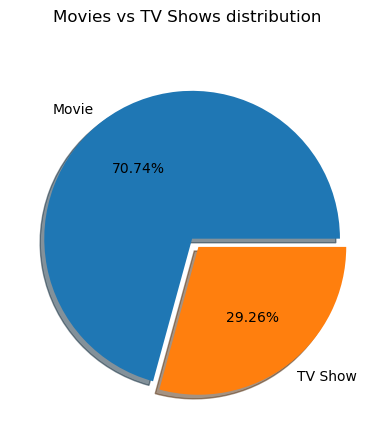

In [64]:

plt.pie(df["type"].value_counts(),labels=df["type"].value_counts().index,
autopct="%1.2f%%",explode=[0.03,0.04], shadow=True)
plt.suptitle('Movies vs TV Shows distribution')
plt.show()

**Insight:** Movies make up a clear majority of Netflix's catalog compared to TV Shows *(read the exact percentages off the pie chart above)*. This suggests Netflix's licensed/original library still leans toward standalone films over multi-season series, though TV Shows tend to drive longer-term subscriber retention — worth flagging as a strategic trade-off.

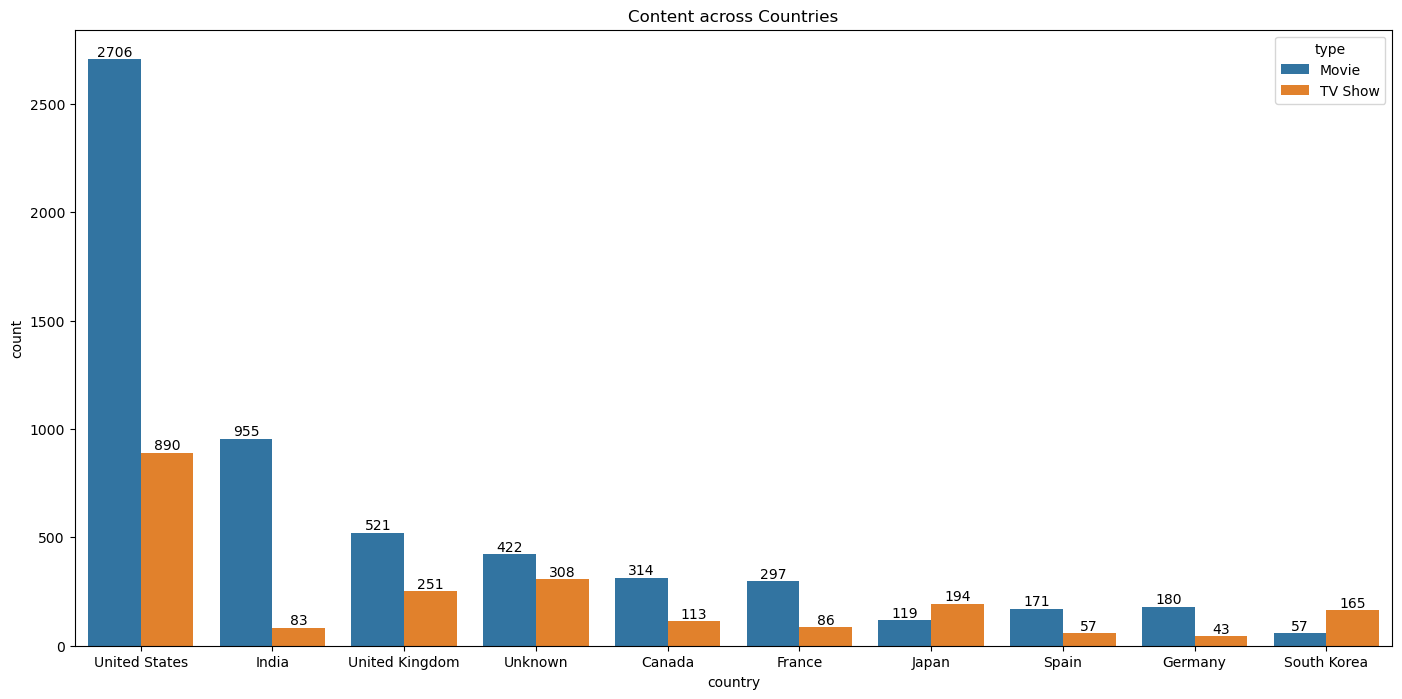

In [65]:
df_temp = df_new.drop_duplicates(subset = ['country', 'title'])
df_temp


x = df_temp['country' ].value_counts().head(10)
x

plt.figure(figsize = (17,8))
plt.title('Content across Countries')
label = sns.countplot(data = df_temp, x = 'country', hue = 'type', order=x. index)
for i in label.containers:
    label.bar_label(i)
plt.show()

**Insight:** Content production is heavily concentrated in a handful of countries — the **United States leads by a wide margin**, with a small set of other countries ( e.g. India, UK etc.) making up most of the remainder. Most other countries contribute a comparatively small share, highlighting how unevenly Netflix's content investment is spread globally.

C:\Users\krish\AppData\Local\Temp\ipykernel_22132\2549831438.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label = sns.countplot(data=df_movies_temp, x='director', order = x.index, palette="husl")
C:\Users\krish\AppData\Local\Temp\ipykernel_22132\2549831438.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label = sns.countplot(data=df_tvs_temp, x='director', order = y. index, palette="husl")


Text(0.5, 0, 'Directors')

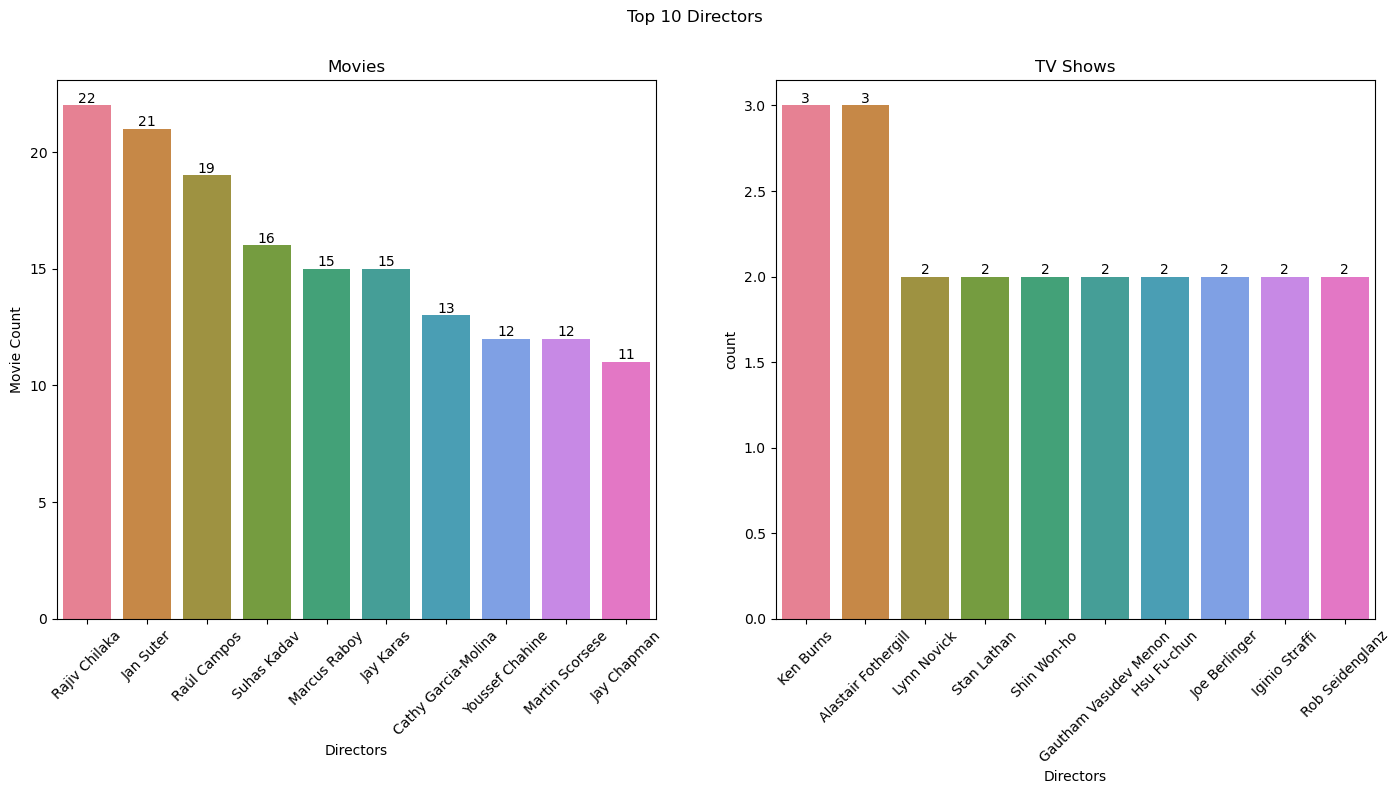

In [66]:
df_movies_temp = df_movies.drop_duplicates(subset = ['director', 'title'])
df_tvs_temp = df_tvs.drop_duplicates(subset = ['director', 'title'])

plt.figure(figsize = (17,7))
plt. suptitle('Top 10 Directors')

plt. subplot(1,2,1)
x=df_movies_temp['director' ].value_counts() [1:11]
label = sns.countplot(data=df_movies_temp, x='director', order = x.index, palette="husl")
for i in label.containers:
    label.bar_label(i)
plt.title("Movies")
plt.xticks(rotation=45)
plt.xlabel('Directors')
plt.ylabel('Movie Count')


plt.subplot(1,2,2)
y=df_tvs_temp['director' ]. value_counts( ) [1:11]
label = sns.countplot(data=df_tvs_temp, x='director', order = y. index, palette="husl")
for i in label.containers:
    label.bar_label(i)
plt.title("TV Shows")
plt.xticks(rotation=45)
plt.xlabel('Directors')

**Insight:** A small number of directors account for a disproportionate share of titles in both Movies and TV Shows *(Rajiv Chilaka, Jan Sulter, Ken Burns etc.)*. This concentration suggests Netflix relies on a core group of repeat collaborators/prolific creators rather than a broad, evenly-distributed pool of directors.

C:\Users\krish\AppData\Local\Temp\ipykernel_22132\2690872084.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label = sns.countplot(data= df_movies_temp, x='genre', order = x.index, palette="husl")
C:\Users\krish\AppData\Local\Temp\ipykernel_22132\2690872084.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label = sns.countplot(data=df_tvs_temp, x='genre',


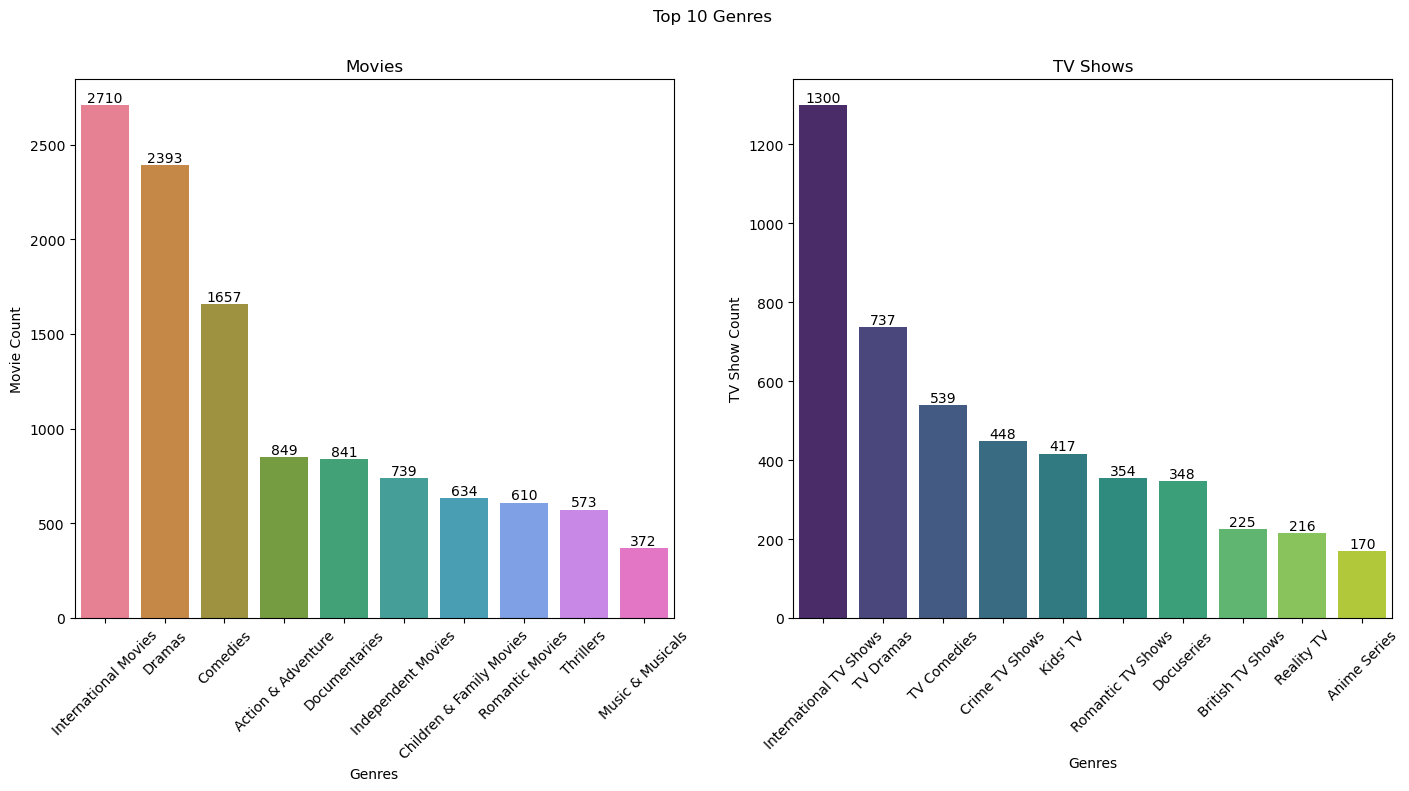

In [67]:
df_movies_temp = df_movies.drop_duplicates(subset = ['genre', 'title'])
df_tvs_temp = df_tvs.drop_duplicates(subset = ['genre', 'title'])

plt.figure(figsize = (17,7))
plt.suptitle('Top 10 Genres')

plt.subplot(1,2,1)
x=df_movies_temp['genre' ].value_counts().head(10)
label = sns.countplot(data= df_movies_temp, x='genre', order = x.index, palette="husl")
for i in label.containers:
    label.bar_label(i)
plt.title("Movies")
plt.xticks(rotation=45)
plt.xlabel('Genres')
plt.ylabel('Movie Count')



plt. subplot(1, 2,2)
y=df_tvs_temp['genre' ].value_counts().head(10)
label = sns.countplot(data=df_tvs_temp, x='genre',
                       order = y.index, palette="viridis")
for i in label.containers:
    label.bar_label(i)
plt.title("TV Shows")
plt.xticks(rotation=45)
plt.xlabel('Genres')
plt.ylabel('TV Show Count')
plt.show()

**Insight:** The top 2-3 genres from thr above charts, e.g. Dramas, International Movies, Documentaries dominate the catalog for both Movies and TV Shows. This shows where Netflix's content strategy is concentrated and can hint at what audience segments are prioritized.

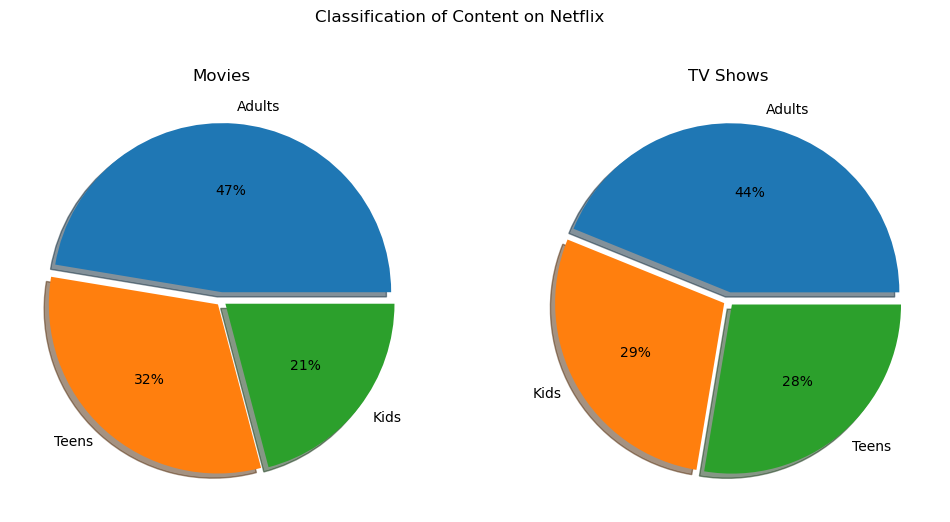

In [68]:
df_movies_temp = df_movies.drop_duplicates(subset = ['rating', 'title'])
df_tvs_temp = df_tvs.drop_duplicates(subset = ['rating', 'title'])

plt.figure(figsize = (12,6))
plt.suptitle('Classification of Content on Netflix')

plt.subplot(1,2,1)
plt.pie(df_movies_temp['rating'].value_counts(),
        labels = df_movies_temp['rating' ].value_counts().index,
        autopct='%0.0f%%', explode = (0.05,0.03,0.03), shadow = True)
plt.title('Movies')

plt.subplot(1,2,2)
plt.pie(df_tvs_temp['rating'].value_counts(),
        labels = df_tvs_temp['rating' ].value_counts().index,
        autopct='%0.0f%%', explode = (0.05,0.03,0.03), shadow = True)
plt.title('TV Shows')

plt.show()

**Insight:** Adults lead both formats (47% Movies, 44% TV Shows), but Movies skew more toward Teens (32%) while TV Shows split Kids/Teens almost evenly (29%/28%). 

In [69]:
df_movies_temp= df_movies.drop_duplicates(subset =['year', 'title'])
df_movies_temp

,type,title,date_added,release_year,rating,duration,day,month,year,month_name,weekday,country,director,cast,genre
0,Movie,Dick Johnson Is Dead,2021-09-25,2020,Teens,90,25,9,2021,September,Saturday,United States,Kirsten Johnson,Unknown,Documentaries
157,Movie,My Little Pony: A New Generation,2021-09-24,2021,Kids,91,24,9,2021,September,Friday,Unknown,Robert Cullen,Vanessa Hudgens,Children & Family Movies
177,Movie,Sankofa,2021-09-24,1993,Adults,125,24,9,2021,September,Friday,United States,Haile Gerima,Kofi Ghanaba,Dramas
329,Movie,The Starling,2021-09-24,2021,Teens,104,24,9,2021,September,Friday,United States,Theodore Melfi,Melissa McCarthy,Comedies
426,Movie,Je Suis Karl,2021-09-23,2021,Adults,127,23,9,2021,September,Thursday,Germany,Christian Schwochow,Luna Wedler,Dramas
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198282,Movie,Zinzana,2016-03-09,2015,Adults,96,9,3,2016,March,Wednesday,United Arab Emirates,Majid Al Ansari,Ali Suliman,Dramas
198318,Movie,Zodiac,2019-11-20,2007,Adults,158,20,11,2019,November,Wednesday,United States,David Fincher,Mark Ruffalo,Cult Movies
198348,Movie,Zombieland,2019-11-01,2009,Adults,88,1,11,2019,November,Friday,United States,Ruben Fleischer,Jesse Eisenberg,Comedies
198362,Movie,Zoom,2020-01-11,2006,Kids,88,11,1,2020,January,Saturday,United States,Peter Hewitt,Tim Allen,Children & Family Movies


In [70]:
mv_year = df_movies_temp['year'].value_counts()
mv_year.sort_index(inplace=True)
mv_year

year
2008       1
2009       2
2011      13
2012       3
2013       3
2014      19
2015      51
2016     224
2017     813
2018    1223
2019    1412
2020    1281
2021     986
Name: count, dtype: int64

In [71]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 
               'October','November', 'December']
mv_month = df_movies_temp['month_name'].value_counts().loc[month_order]
mv_month

month_name
January      535
February     375
March        518
April        542
May          433
June         485
July         559
August       515
September    510
October      535
November     489
December     535
Name: count, dtype: int64

In [72]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
mv_day = df_movies_temp['weekday'].value_counts().loc[day_order]
mv_day

weekday
Monday        612
Tuesday       842
Wednesday     895
Thursday     1040
Friday       1537
Saturday      543
Sunday        562
Name: count, dtype: int64

C:\Users\krish\AppData\Local\Temp\ipykernel_22132\3279898078.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label = sns.countplot(data=df_movies_temp, x='year', order = mv_year.index, palette='viridis')
C:\Users\krish\AppData\Local\Temp\ipykernel_22132\3279898078.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label = sns.countplot(data=df_movies_temp, x='month_name',
C:\Users\krish\AppData\Local\Temp\ipykernel_22132\3279898078.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label = sns.countplot(data=df_movies_temp, x='weekday',


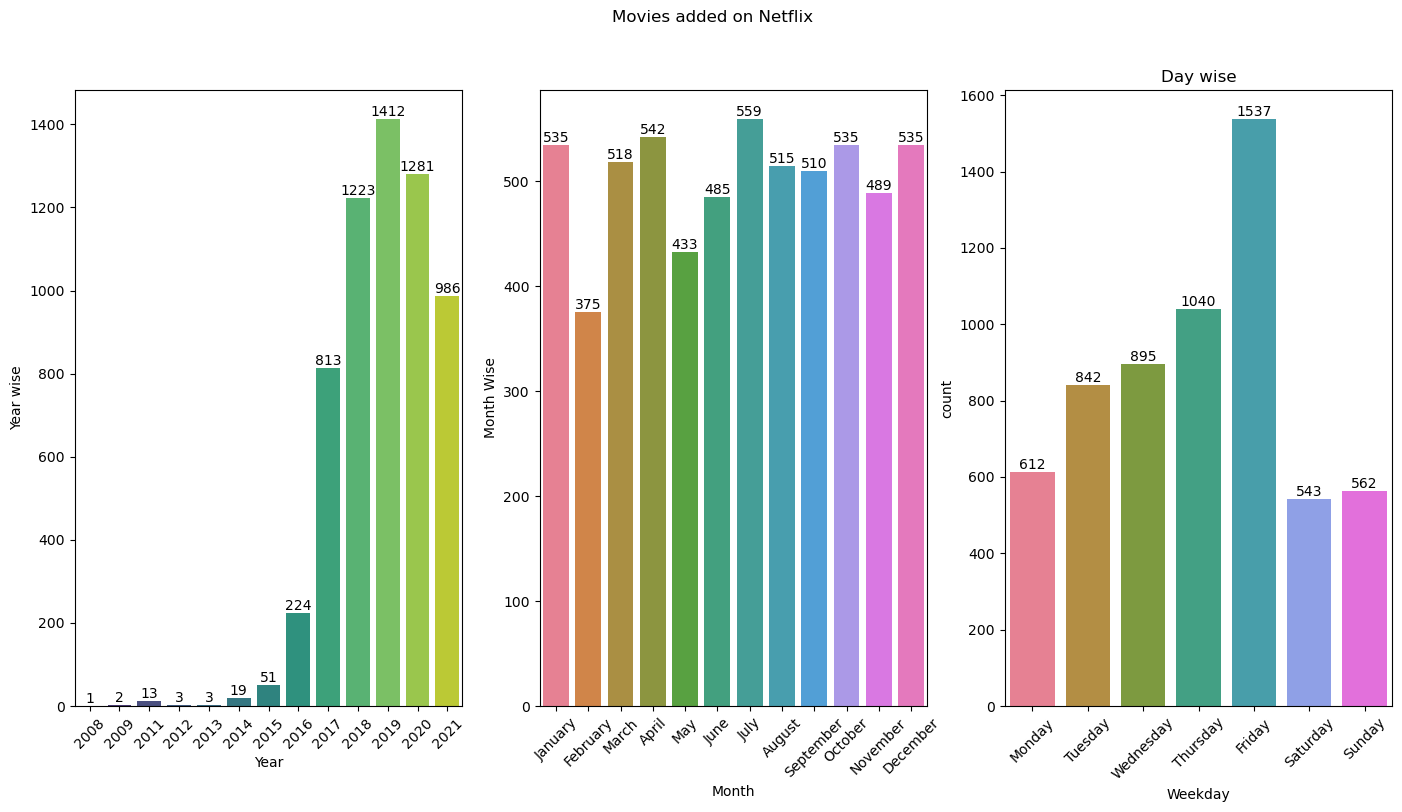

In [73]:
plt.figure(figsize=(17,8))
plt.suptitle('Movies added on Netflix')

plt.subplot(1,3,1)
label = sns.countplot(data=df_movies_temp, x='year', order = mv_year.index, palette='viridis')
for i in label.containers:
    label.bar_label(i)
plt.xticks(rotation=45)
plt.xlabel('Year')
plt.ylabel('Year wise')


plt.subplot(1,3,2)
label = sns.countplot(data=df_movies_temp, x='month_name',
                     order = mv_month.index,palette='husl')
for i in label.containers:
    label.bar_label(i)
plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Month Wise')


plt.subplot(1,3,3)
label = sns.countplot(data=df_movies_temp, x='weekday',
                      order = mv_day.index, palette="husl")
for i in label.containers:
    label.bar_label(i)
plt.xticks(rotation=45)
plt.xlabel('Weekday')
plt.title('Day wise')
plt.show()

**Insight:** Movie additions to Netflix grew steadily from a handful of titles before 2014 to a peak of **1,412 movies added in 2019**, before declining in 2020 (1,281) and 2021 (986) — likely reflecting production slowdowns during the COVID-19 pandemic. By month, **July (559)** sees the most additions and **February (375)** the fewest (partly explained by fewer days in February). By day of week, **Friday is by far the most common release day (1,537 additions)**, more than double the next-lowest weekday (Monday, 612) — a strong signal that Netflix deliberately times releases to precede the weekend and maximize viewership.

In [74]:
df_tvs_temp = df_tvs.drop_duplicates(subset = ['year', 'title'])

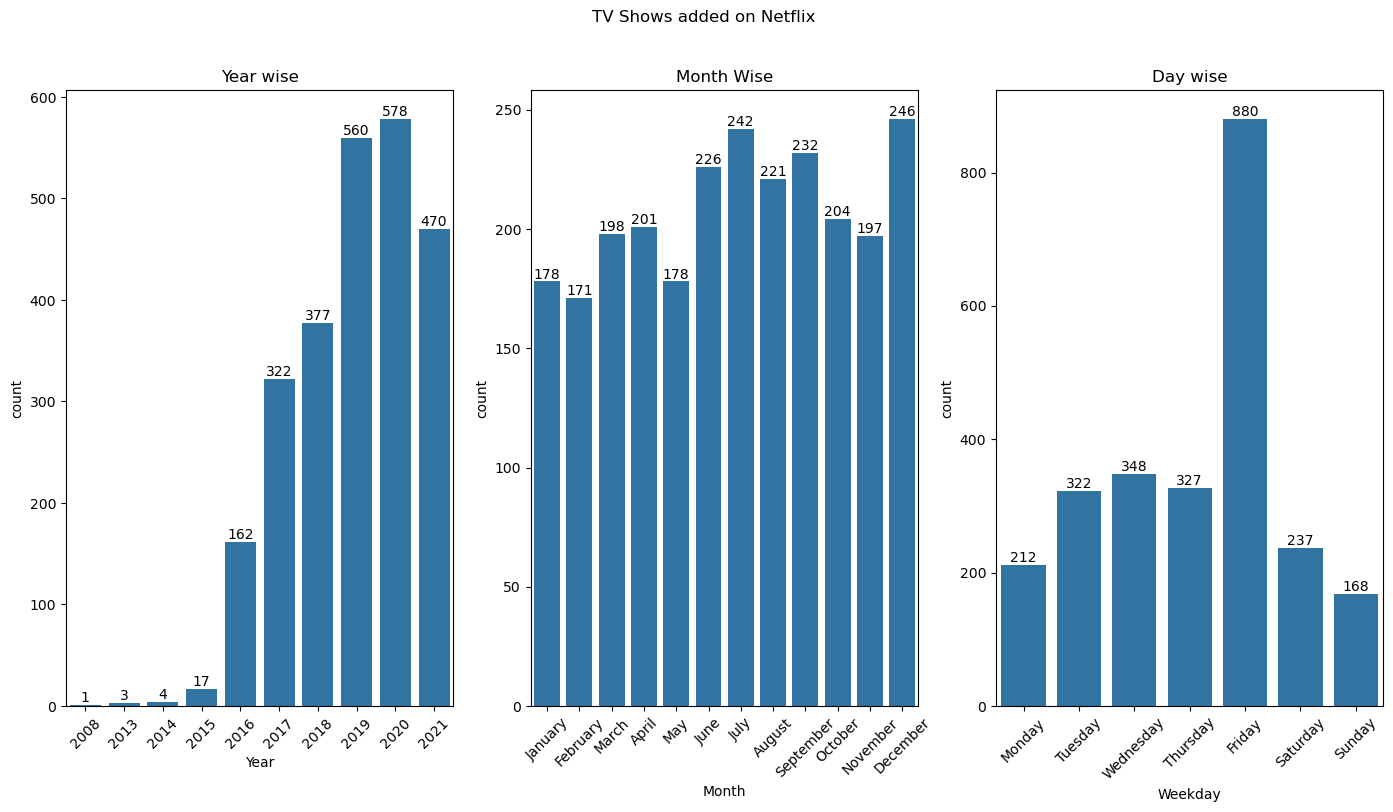

In [76]:
tv_year = df_tvs_temp['year'].value_counts()
tv_year.sort_index(inplace=True)

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November','December']
tv_month = df_tvs_temp['month_name'].value_counts().loc[month_order]

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
tv_day = df_tvs_temp['weekday'].value_counts().loc[day_order ]

plt.figure(figsize=(17,8))
plt.suptitle('TV Shows added on Netflix')

plt.subplot(1,3,1)
label = sns.countplot(data=df_tvs_temp, x='year', order = tv_year.index)
for i in label.containers:
    label.bar_label(i)
plt.xticks(rotation=45)
plt.xlabel('Year')
plt.title('Year wise')



plt.subplot(1,3,2)
label = sns.countplot(data=df_tvs_temp, x='month_name', order = tv_month.index)
for i in label.containers:
    label.bar_label(i)
plt.xticks(rotation=45)
plt.xlabel('Month')
plt.title('Month Wise')


plt.subplot(1,3,3)
label = sns.countplot(data=df_tvs_temp, x='weekday', order = tv_day.index)
for i in label.containers:
    label.bar_label(i)
plt.xticks(rotation=45)
plt.xlabel('Weekday')
plt.title('Day wise')
plt.show()

**Insight:** Movie releases grew slowly until 2015, then surged from 2016 onward, peaking at 578 titles in 2020 before dipping to 470 in 2021 — likely reflecting either a strategic slowdown or incomplete data for that year. Monthly counts are fairly balanced (171–246 range), with mild peaks in July and December, suggesting some seasonal/holiday timing. The weekday pattern stands out most: Friday dominates with 880 releases, more than double the next-highest day (Wednesday, 348), showing a clear, deliberate strategy of launching movies at the start of the weekend to maximize early viewership — while actual weekend days (Saturday, Sunday) see comparatively fewer releases.

Here, we are replacing the column duration with a better name season for tv shows only in df_tvs.

In [80]:
df_tvs.rename(columns={'duration' : 'seasons' }, inplace=True)

C:\Users\krish\AppData\Local\Temp\ipykernel_22132\897253341.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tvs.rename(columns={'duration' : 'seasons' }, inplace=True)


Lets see the average duration of a movie and a average season of TV Show

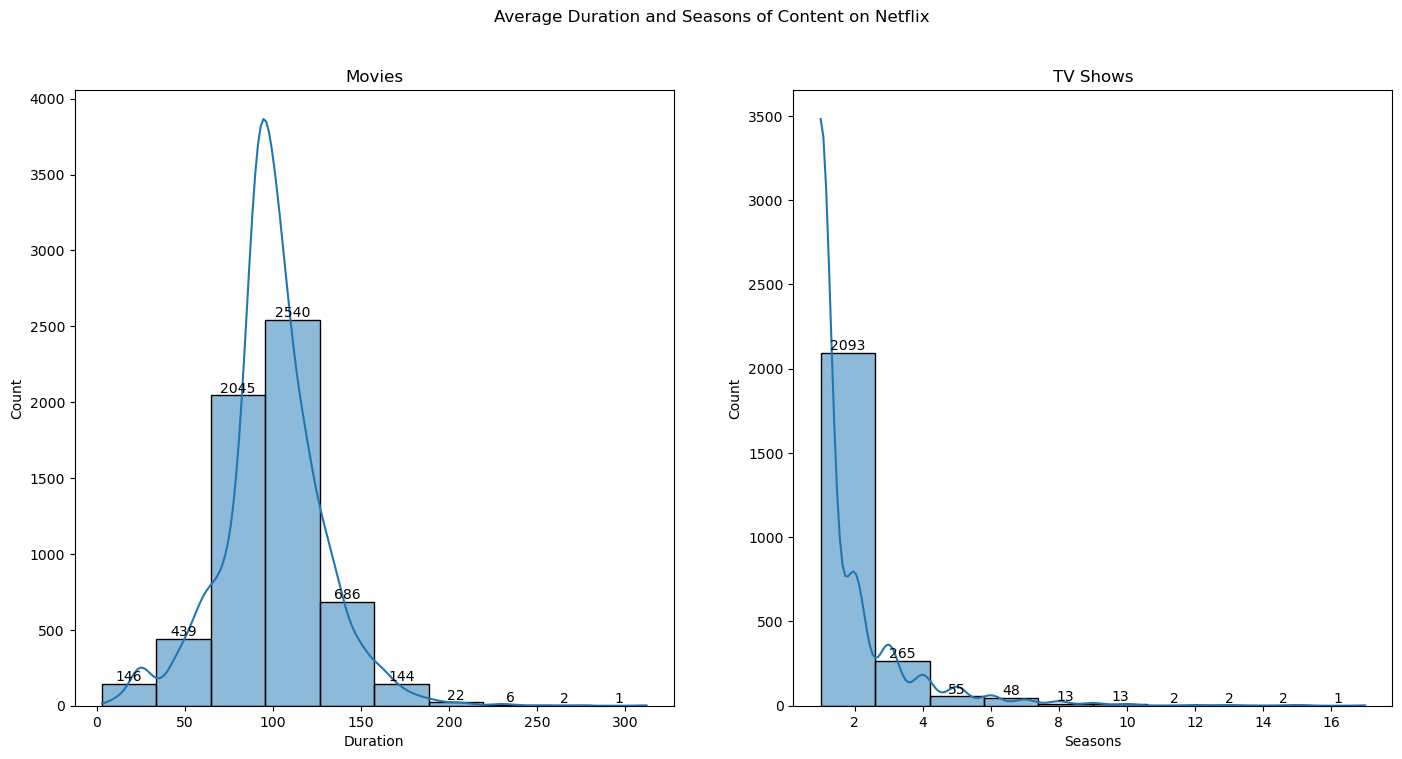

In [81]:
df_movies_temp = df_movies.drop_duplicates(subset = ['duration', 'title'])
df_tvs_temp = df_tvs.drop_duplicates(subset = ['seasons', 'title'])

plt.figure(figsize=(17,8))
plt.suptitle('Average Duration and Seasons of Content on Netflix')

plt.subplot(1,2,1)
label = sns.histplot(df_movies_temp['duration'], bins = 10, kde = True)
for i in label.containers:
    label.bar_label(i)
plt.xlabel('Duration')
plt.title('Movies')

plt.subplot(1,2,2)
label = sns.histplot(df_tvs_temp['seasons'], bins=10, kde = True)
for i in label.containers:
    label.bar_label(i)
plt.xlabel('Seasons')
plt.title('TV Shows')
plt.show()

**Insight:** Most movies cluster around a typical runtime *( ~75-175 minutes)*, while most TV shows have just **1-2 seasons**, with very few running longer — consistent with Netflix's catalog being dominated by limited series and one-off films rather than long-running shows.

Lets see the range of most movie's duration and tv show's seasons lie.

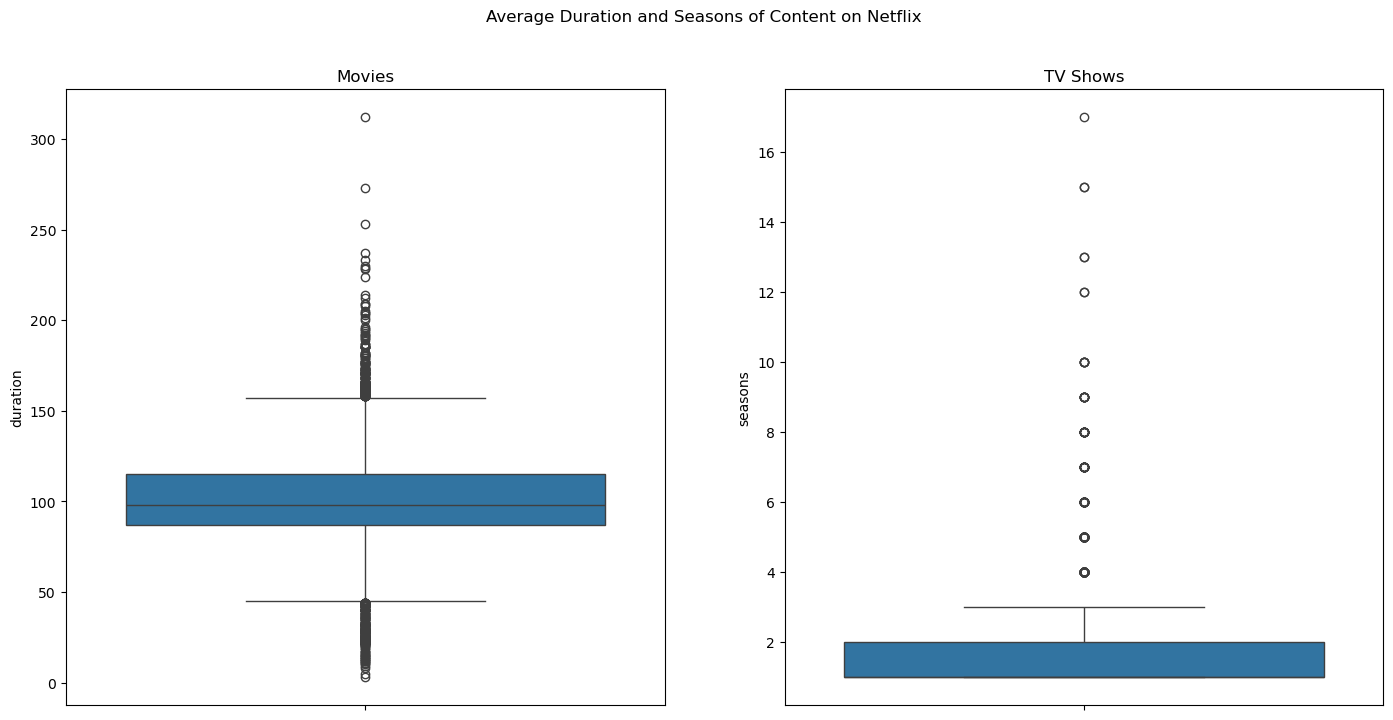

In [82]:
plt.figure(figsize=(17,8))
plt. suptitle('Average Duration and Seasons of Content on Netflix')

plt.subplot(1,2,1)
sns. boxplot(y=df_movies_temp["duration"])
plt.title('Movies')

plt.subplot(1,2,2)
sns. boxplot(y=df_tvs_temp['seasons' ])
plt.title('TV Shows')
plt.show()

## Key Findings- 

Movies significantly outnumber TV Shows in Netflix's catalog.
- The **United States** is the largest content contributor by far, with a small set of other countries making up most of the remainder.
- Content is concentrated in a few dominant genres and a core group of prolific directors.
- **Adult-rated content** *(confirm from your chart)* forms the largest share of both Movies and TV Shows.
- Content additions **grew steadily until peaking in 2019 (1,412 movies)**, then declined in 2020-2021, likely due to pandemic-related production disruptions.
- **Friday is overwhelmingly the preferred content-release day** (1,537 additions vs. 612 on Monday)— a deliberate strategy to maximize weekend viewership.
- **Most TV shows run for only 1-2 seasons**, while movie runtimes cluster in a fairly narrow, typical range.



- ## Business Recommendations:
- The strong Friday-release pattern is worth formalizing as a scheduling strategy across all regions and genres, since it appears to already be working as an engagement lever.
- The heavy US/India-centric content mix suggests room to diversify investment into under-represented regions to grow international subscriber bases.- Given TV Shows' role in long-term retention, and their comparatively smaller share of the catalog, increasing multi-season TV investment could complement the movie-heavy library.




## Limitations:
- The dataset is a static snapshot, not a live feed — it does not reflect content added after its collection date.
- Rows with missing `date_added`, `rating`, or `duration` were dropped rather than imputed, which slightly reduces the dataset size but avoids introducing inaccurate estimates.
- Because `cast`, `director`, `country`, and `genre` were "unnested" (one row per value), frequency-based charts (e.g. top directors) can be biased toward titles that simply have more contributors listed, not necessarily toward higher quality or popularity.




## Future Scope:
- Combine with IMDb/Rotten Tomatoes ratings to analyze quality vs. quantity of content by country/genre.
- Build a recommendation system using genre and cast similarity.
- Perform time-series forecasting on content additions to project future catalog growth.